In [5]:
import gymnasium as gym
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches

## Value iterator

In [21]:
def value_iteration(entorno, gamma_p, theta_p):
    
    """
    Implementa el algoritmo Value Iteration (Iteración de Valor).

    Fundamento teórico:
    -------------------
    Aplica la ecuación de Bellman iterativamente sobre todos los estados
    hasta convergencia. En cada barrida actualiza:

        V(s) = max_a { Σ P(s'|s,a) · [R + γ · V(s')] }

    Al converger, extrae la política óptima:
        π*(s) = argmax_a Q(s,a)

    Parámetros:
    -----------
    entorno : gym.Env  — entorno Gym con acceso a entorno.P (modelo del entorno)
    gamma   : float    — factor de descuento (0 < γ ≤ 1)
    theta   : float    — criterio de convergencia (umbral de cambio mínimo)

    Retorna:
    --------
    V       : np.ndarray — función de valor óptima para cada estado
    politica: np.ndarray — política óptima (acción por estado)
    iteraciones: int     — cantidad de iteraciones hasta convergencia
    """

    iteracion = 0
    modelo = entorno.unwrapped.P
    num_estados = entorno.observation_space.n
    num_acciones = entorno.action_space.n
    V = np.zeros(num_estados)
    
    while True:
        delta = 0.0

        for s in range(num_estados):
            valor_anterior = V[s]
            valores_q = np.zeros(num_acciones)

            for a in range(num_acciones):
                for prob, siguiente, recompensa, terminado in modelo[s][a]:
                    valores_q[a] += prob * (recompensa + gamma_p * V[siguiente])

            # Guardamos el máximo valor encontrado entre las acciones
            V[s] = max(valores_q)

            # Calcular el cambio máximo para la condición de parada
            delta = max(delta, abs(valor_anterior - V[s]))

        iteracion += 1
        ##print(f"Iteración {iteracion}: V = {np.round(V, 2)}")

        if delta < theta_p:
            break

    politica_estados = {}
    for s in range(num_estados):
        valores_q = np.zeros(num_acciones)
        for a in range(num_acciones):
            for prob, siguiente, recompensa, terminado in modelo[s][a]:
                valores_q[a] += prob * (recompensa + gamma_p * V[siguiente])

        politica_estados[s] = np.argmax(valores_q)
    return V, politica_estados



def impresion_matriz_v_y_politica(nombre, matriz, policy, dim):
    print(f"Matriz {nombre} de Valores:")
    print(np.round(matriz.reshape(dim, dim), 4))
    print("\nPolítica Óptima:")
    flechas = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    lista_flechas = [flechas[accion] for accion in policy.values()]
    policy_formateado = np.array(lista_flechas).reshape(dim, dim)
    print(policy_formateado)




def graficar_valor_iteration(V_det, V_esto, nombre_archivo, dim):

    if dim == 4:
        MAPA_FROZEN_LAKE = ["SFFF", "FHFH", "FFFH", "HFFG"]
    else:
        MAPA_FROZEN_LAKE = ["SFFFFFFF","FFFFFFFF","FFFHFFFF","FFFFFHFF","FFFHFFFF","FHHFFFHF","FHFFHFHF","FFFHFFFG"]
    fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
        f"Value Iteration — Función de Valor V*(s) — FrozenLake {dim}×{dim}",
        fontsize=14,
        fontweight="bold",
    )

    for i, (V, modo) in enumerate([(V_det, "Determinístico"), (V_esto, "Estocástico")]):
        grilla = V.reshape(dim, dim)
        im = ejes[i].imshow(
            grilla,
            cmap="YlOrRd",
            interpolation="nearest",
            vmin=0,
            vmax=max(V.max(), 0.01),
        )
        ejes[i].set_title(f"Modo {modo}", fontsize=12)

        # Anotar cada celda con su valor
        for fila in range(dim):
            for col in range(dim):
                celda = MAPA_FROZEN_LAKE[fila][col]
                texto = celda if celda in ("H", "G") else f"{grilla[fila, col]:.3f}"
                color = "black" if grilla[fila, col] < 0.5 else "white"
                ejes[i].text(
                    col,
                    fila,
                    texto,
                    ha="center",
                    va="center",
                    fontsize=11,
                    color=color,
                    fontweight="bold",
                )

        ejes[i].set_xticks(range(dim))
        ejes[i].set_yticks(range(dim))
        ejes[i].set_xticklabels(range(dim))
        ejes[i].set_yticklabels(range(dim))
        ejes[i].set_xlabel("Columna")
        ejes[i].set_ylabel("Fila")
        plt.colorbar(im, ax=ejes[i], label="V*(s)")

    plt.tight_layout()
    plt.savefig(nombre_archivo);
    plt.show()


def graficar_politica_frozen_lake(
    politica_det, politica_esto, V_det, V_esto, nombre_archivo, dim
):
    if dim == 4:
        MAPA_FROZEN_LAKE = ["SFFF", "FHFH", "FFFH", "HFFG"]
    else:
        MAPA_FROZEN_LAKE = ["SFFFFFFF","FFFFFFFF","FFFHFFFF","FFFFFHFF","FFFHFFFF","FHHFFFHF","FHFFHFHF","FFFHFFFG"]
    SIMBOLOS_ACCIONES = {"frozen_lake": {0: "←", 1: "↓", 2: "→", 3: "↑"}}
    """Visualiza las políticas óptimas de ambos modos como flechas en grilla."""
    simbolos = SIMBOLOS_ACCIONES["frozen_lake"]
    fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Política Óptima — FrozenLake {dim}×{dim}", fontsize=14, fontweight="bold")

    for i, (politica, V, modo) in enumerate(
        [
            (politica_det, V_det, "Determinístico"),
            (politica_esto, V_esto, "Estocástico"),
        ]
    ):
        grilla = V.reshape(dim, dim)
        colores = ["#FFFFFF", "#000000", "#008000"]  # Blanco, Negro y Verde
        cmap_personalizado = mcolors.ListedColormap(colores)
        
        ejes[i].set_title(f"Modo {modo}", fontsize=12)
        
        matriz_fondo = np.zeros((dim, dim))
        for fila in range(dim):
            for col in range(dim):
                rect = patches.Rectangle(
                    (col - 0.5, fila - 0.5), 
                    1, 1, 
                    linewidth=2,       # Grosor del borde negro
                    edgecolor='black', # Color del borde
                    facecolor='none'   # Sin relleno para no tapar el fondo colorido
                )
                ejes[i].add_patch(rect)
                celda = MAPA_FROZEN_LAKE[fila][col]
                if celda == "H":
                    matriz_fondo[fila][col] = 1  # Pintará Rojo
                elif celda == "G":
                    matriz_fondo[fila][col] = 2  # Pintará Azul/Celeste

        # 3. Dibujamos el fondo de color
        ejes[i].imshow(
            matriz_fondo, cmap=cmap_personalizado, vmin=0, vmax=2
        )

        
     
        for fila in range(dim):
            for col in range(dim):
                estado = fila * dim + col
                celda = MAPA_FROZEN_LAKE[fila][col]
                if celda == "H":
                    ejes[i].text(
                        col,
                        fila,
                        "",
                        ha="center",
                        va="center",
                        fontsize=20,
                        color="red",
                        fontweight="bold",
                    )
                elif celda == "G":
                    ejes[i].text(
                        col,
                        fila,
                        "",
                        ha="center",
                        va="center",
                        fontsize=20,
                        color="gold",
                        fontweight="bold",
                    )
                else:
                    flecha = simbolos[politica[estado]]
                    ejes[i].text(
                        col,
                        fila,
                        flecha,
                        ha="center",
                        va="center",
                        fontsize=22,
                        color="black",
                        fontweight="bold",
                    )

        ejes[i].set_xticks(range(dim))
        ejes[i].set_yticks(range(dim))
        ejes[i].set_xticks(np.arange(-0.5, dim, 1), minor=True)
        ejes[i].set_yticks(np.arange(-0.5, dim, 1), minor=True)
        ejes[i].grid(False)
        ejes[i].tick_params(which="both", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig(nombre_archivo);
    plt.show()


In [22]:
##codigo para ejecutar frozen lake mas rapido
def ejecutar_frozen_lake(bool_estocastico, dimension):
    if bool_estocastico:
        tipo_matriz = "ESTOCÁSTICO"
    else: 
        tipo_matriz = "DETERMINISTA"
    print(f"FROZEN LAKE {tipo_matriz} {dimension}x{dimension}")
    conjunto_recompensas = []
    suma = 0
    for i in range(30):
        env = gym.make("FrozenLake-v1", is_slippery=bool_estocastico, map_name=f"{dimension}x{dimension}")
        observation, info = env.reset()
        
        episode_over = False
        total_reward = 0
        gamma = 0.99
        theta = 1e-8
        
        matriz_costos_v, politica = value_iteration(env, gamma, theta)
        
        if i==0:
            impresion_matriz_v_y_politica(tipo_matriz, matriz_costos_v, politica, dimension)
        
        estado_actual = observation
        while not episode_over:
            action = politica.get(estado_actual)
            estado_actual, reward, terminated, truncated, info = env.step(action)
        
            total_reward += reward
        
            episode_over = terminated or truncated
            
        print(f"Ejecución {i + 1}: Recompensa = {total_reward}")
        conjunto_recompensas.append(total_reward)
        suma += total_reward
        env.close()
    
    porcentaje_exitos = suma / 30 * 100
    print(f"\nPorcentaje de exitos: {porcentaje_exitos:.4f}%")
    
    return matriz_costos_v, politica, conjunto_recompensas

In [23]:
# Ejecución de Frozen Lake en un entorno Determinista.

FROZEN LAKE DETERMINISTA 4x4
Matriz DETERMINISTA de Valores:
[[0.951  0.9606 0.9703 0.9606]
 [0.9606 0.     0.9801 0.    ]
 [0.9703 0.9801 0.99   0.    ]
 [0.     0.99   1.     0.    ]]

Política Óptima:
[['↓' '→' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '↓' '↓' '←']
 ['←' '→' '→' '←']]
Ejecución 1: Recompensa = 1
Ejecución 2: Recompensa = 1
Ejecución 3: Recompensa = 1
Ejecución 4: Recompensa = 1
Ejecución 5: Recompensa = 1
Ejecución 6: Recompensa = 1
Ejecución 7: Recompensa = 1
Ejecución 8: Recompensa = 1
Ejecución 9: Recompensa = 1
Ejecución 10: Recompensa = 1
Ejecución 11: Recompensa = 1
Ejecución 12: Recompensa = 1
Ejecución 13: Recompensa = 1
Ejecución 14: Recompensa = 1
Ejecución 15: Recompensa = 1
Ejecución 16: Recompensa = 1
Ejecución 17: Recompensa = 1
Ejecución 18: Recompensa = 1
Ejecución 19: Recompensa = 1
Ejecución 20: Recompensa = 1
Ejecución 21: Recompensa = 1
Ejecución 22: Recompensa = 1
Ejecución 23: Recompensa = 1
Ejecución 24: Recompensa = 1
Ejecución 25: Recompensa = 1
Eje

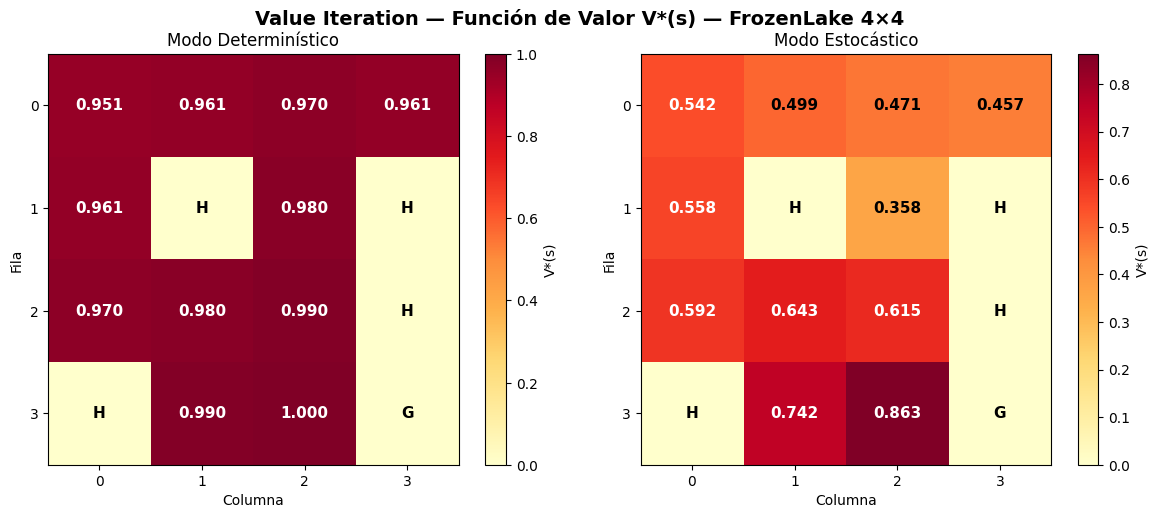

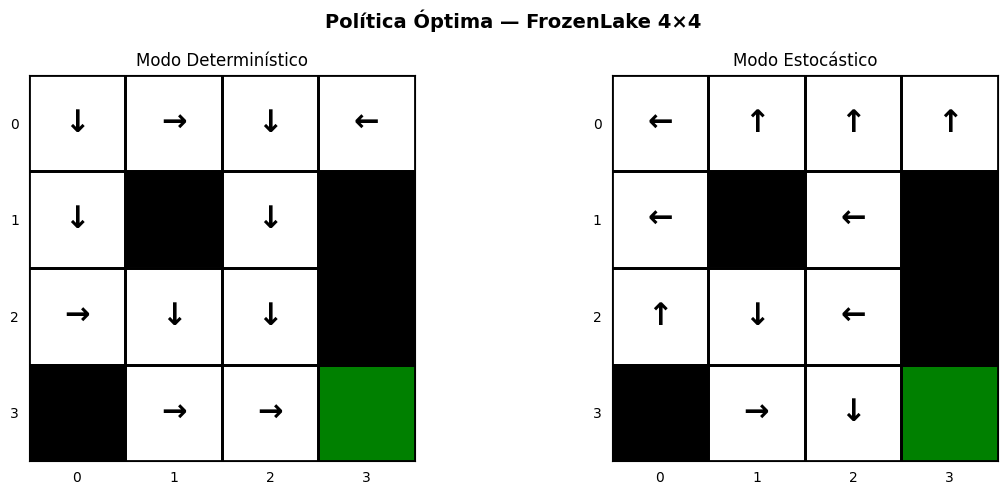

In [24]:
dimension = 4
matriz_costos_v_determinista, politica_determinista, recompensas_determinista = ejecutar_frozen_lake(False, dimension)

print("\n\n\n\n")
matriz_costos_v_estocastica, politica_estocastica, recompensas_estocastica = ejecutar_frozen_lake(True, dimension)

print("\n\n\n\n")
graficar_valor_iteration(matriz_costos_v_determinista, matriz_costos_v_estocastica, "value_iteration_4x4.png", dimension)
graficar_politica_frozen_lake(politica_determinista, politica_estocastica, matriz_costos_v_determinista, matriz_costos_v_estocastica,"politica_4x4.png", dimension)

conclusiones

# Ejecución de Frozen Lake en un entorno 8x8.

FROZEN LAKE DETERMINISTA 8x8
Matriz DETERMINISTA de Valores:
[[0.8775 0.8864 0.8953 0.9044 0.9135 0.9227 0.9321 0.9415]
 [0.8864 0.8953 0.9044 0.9135 0.9227 0.9321 0.9415 0.951 ]
 [0.8953 0.9044 0.9135 0.     0.9321 0.9415 0.951  0.9606]
 [0.9044 0.9135 0.9227 0.9321 0.9415 0.     0.9606 0.9703]
 [0.8953 0.9044 0.9135 0.     0.951  0.9606 0.9703 0.9801]
 [0.8864 0.     0.     0.951  0.9606 0.9703 0.     0.99  ]
 [0.8953 0.     0.9321 0.9415 0.     0.9801 0.     1.    ]
 [0.9044 0.9135 0.9227 0.     0.9801 0.99   1.     0.    ]]

Política Óptima:
[['↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓']
 ['↓' '↓' '↓' '→' '↓' '↓' '↓' '↓']
 ['↓' '↓' '↓' '←' '↓' '→' '↓' '↓']
 ['→' '→' '→' '→' '↓' '←' '↓' '↓']
 ['→' '→' '↑' '←' '↓' '↓' '→' '↓']
 ['↓' '←' '←' '→' '→' '↓' '←' '↓']
 ['↓' '←' '→' '↑' '←' '↓' '←' '↓']
 ['→' '→' '↑' '←' '→' '→' '→' '←']]
Ejecución 1: Recompensa = 1
Ejecución 2: Recompensa = 1
Ejecución 3: Recompensa = 1
Ejecución 4: Recompensa = 1
Ejecución 5: Recompensa = 1
Ejecución 6: Recompensa = 1

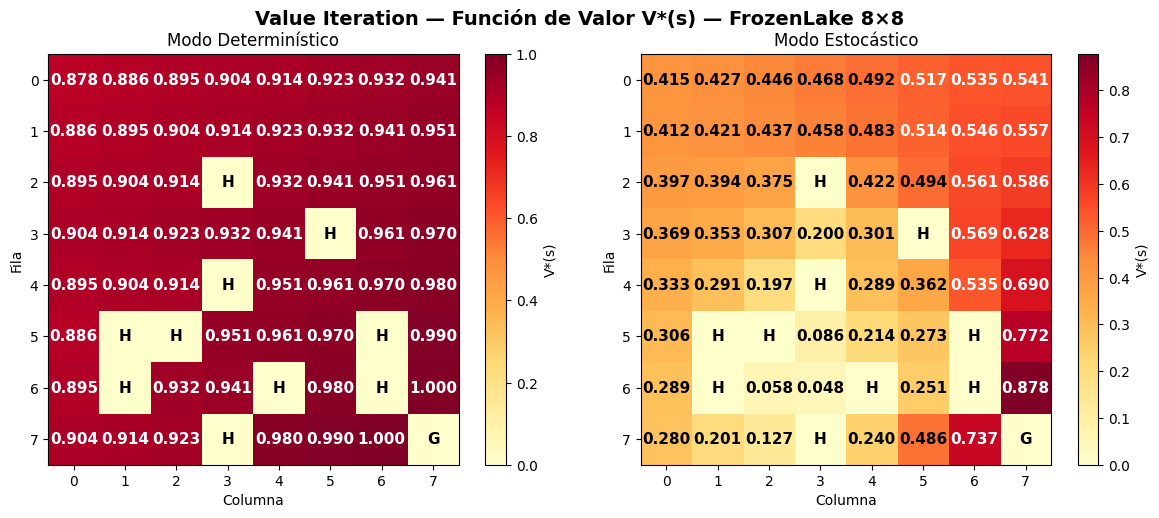

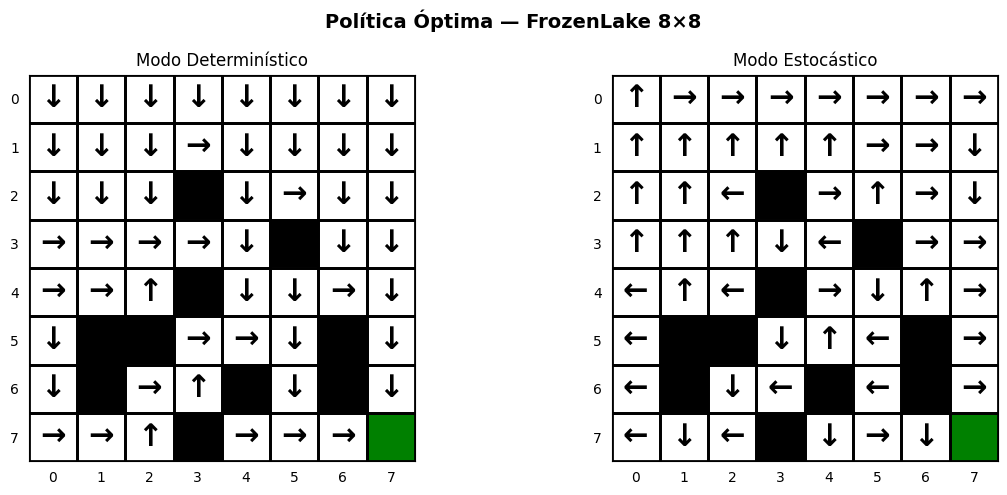

In [25]:
dimension = 8
matriz_costos_v_determinista, politica_determinista, recompensas_determinista = ejecutar_frozen_lake(False, dimension)

print("\n\n\n\n")
matriz_costos_v_estocastica, politica_estocastica, recompensas_estocastica = ejecutar_frozen_lake(True, dimension)

print("\n\n\n\n")
graficar_valor_iteration(matriz_costos_v_determinista, matriz_costos_v_estocastica, "value_iteration_8x8.png", dimension)
graficar_politica_frozen_lake(politica_determinista, politica_estocastica, matriz_costos_v_determinista, matriz_costos_v_estocastica,"politica_8x8.png", dimension)

In [ ]:
conclusiones

# Q-LEARNING

In [1]:
def aprendizaje_q(
    entorno,
    episodios=10000,
    alfa=0.1,
    gamma=0.99,
    epsilon=1.0,
    decaimiento_epsilon=0.999,es_continuo=False,):

    
    num_estados = entorno.observation_space.n
    num_acciones = entorno.action_space.n


    if es_continuo:
        Q = np.zeros((
    len(bins_posicion) + 1,
    len(bins_velocidad) + 1,
    len(bins_angulo) + 1,
    len(bins_vel_angular) + 1,
    num_acciones
))

    Q = np.zeros((num_estados, num_acciones))
    recompensas_por_episodio = []

    for episodio in range(episodios):
        info_estado = entorno.reset()
        estado = info_estado[0]

        if es_continuo:
            estado = discretizar_estado(estado)
            
        recompensa_total = 0
        terminado = False

        while not terminado:

            if np.random.uniform(0, 1) < epsilon:
                accion = entorno.action_space.sample() 
            else:
                accion = np.argmax(Q[estado, :])  

            resultado_accion = entorno.step(accion)

            siguiente_estado, recompensa, finalizado, truncado, _ = resultado_accion
            terminado = finalizado or truncado

            # 3. Actualizar Q mediante la ecuación de aprendizaje (Diferencia Temporal)
            # Calculamos el objetivo DT (Diferencia Temporal)
            # mejor_siguiente_accion = np.argmax(Q[siguiente_estado, :])
            # objetivo_dt = recompensa + gamma * Q[siguiente_estado, mejor_siguiente_accion] * (not terminado)
            # error_dt = objetivo_dt - Q[estado, accion]
            # Q[estado, accion] += alfa * error_dt
            # ESTA ERA LA FORMA ANTERIOR DE CALCULAR, ES LO MISMO LA DE ABAJO PERO EN UNA LINEA

            Q[estado, accion] += alfa * (recompensa + gamma * np.max(Q[siguiente_estado, :]) * (not terminado) - Q[estado, accion])

            estado = siguiente_estado
            recompensa_total += recompensa

        
        epsilon = max(0.01, epsilon * decaimiento_epsilon)
        recompensas_por_episodio.append(recompensa_total)


    politica = np.argmax(Q, axis=1)

    return Q, politica, recompensas_por_episodio


# DOS COSAS A TENER EN CUENTA
# la ecuacion q puede estar implementada en una linea o en varias, decidir eso
# el decaimiento de epsilon se puede hacer al comienzo como en el pseudocodigo pero conlleva que
# o se evite en el primer episodio o que epsilon no sea 100 en el primer intento, lo cual no se si es correcto

# CART POLE

Tiene dos variantes v0 y v1

el agente tiene que mantenerse con el palo en equilibrio lo mas que pueda
 - en v0 -> 200 pasos y umbral de exito 200
 - en v1 -> 500 pasos y umbal de exito 500

dos formas de recompensa
 1. El agente gana puntos por cada paso que sobrevive
 2. El agente no gana puntos pero pierde si se muere

dos formas de que en teoria tienen el mismo resultado pero estaria interesante comparar ambos

In [2]:
def discretizar(observacion, low, high, k):
    indices = []
    for i in range(len(observacion)):
        val = observacion[i]
        mn = low[i]
        mx = high[i]
        
        # Limitar valor usando python puro (10x más rápido que np.clip)
        val_recortado = mn if val < mn else (mx if val > mx else val)
        
        idx = int((val_recortado - mn) / (mx - mn) * k)
        if idx >= k:
            idx = k - 1
        indices.append(idx)
    return tuple(indices)


In [3]:
def apren_q(entorno, episodios=10000, alfa=0.05, gamma=0.99,
                  epsilon=1.0, decaimiento_epsilon=0.999,
                  es_continuo=False, k=11, low=None, high=None):

    num_acciones = entorno.action_space.n

    if es_continuo:
        dimensiones = len(low)
        Q = np.zeros([k] * dimensiones + [num_acciones])
    else:
        Q = np.zeros((entorno.observation_space.n, num_acciones))

    recompensas_por_episodio = []

    for episodio in range(episodios):
        estado, _ = entorno.reset()
        if es_continuo:
            estado = discretizar(estado, low, high, k)

        recompensa_total = 0
        terminado = False

        while not terminado:
            if np.random.uniform(0, 1) < epsilon:
                accion = entorno.action_space.sample()
            else:
                accion = np.argmax(Q[estado])

            siguiente_estado, recompensa, finalizado, truncado, _ = entorno.step(accion)
            terminado = finalizado or truncado


            if es_continuo:
                siguiente_estado = discretizar(siguiente_estado, low, high, k)

            Q[estado][accion] += alfa * (
                recompensa + gamma * np.max(Q[siguiente_estado]) * (not terminado) - Q[estado][accion]
            )

            estado = siguiente_estado
            recompensa_total += recompensa

        epsilon = max(0.01, epsilon * decaimiento_epsilon)
        recompensas_por_episodio.append(recompensa_total)

    politica = np.argmax(Q, axis=-1)   # axis=-1 sirve para 2D y para N-D
    # eso creo que no hace falta porque no hacemos ningun escenario en 3D
    return Q, politica, recompensas_por_episodio

In [6]:
# MountainCar: funciona sin tocar nada, los límites son finitos
# entorno = gym.make("MountainCar-v0")
# Q, politica, recompensas = apren_q(entorno, es_continuo=True)

# CartPole: pasás límites manuales para las variables con inf
low=np.array([-4.8, -3.5, -0.418, -3.5])
high=np.array([ 4.8,  3.5,  0.418,  3.5])
entorno = gym.make("CartPole-v1", sutton_barto_reward=True)
Q, politica, recompensas = apren_q(
    entorno, es_continuo=True,
    low=low,
    high=high,
    k=11,
)

print(politica)


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(politica[9, :, :, 9], cmap='RdYlGn', aspect='auto')
plt.xlabel("Ángulo del polo (bins)")
plt.ylabel("Posición del carrito (bins)")
plt.title("Política - corte en velocidades centrales")
plt.colorbar(label="Acción (0=izq, 1=der)")
plt.show()

In [ ]:

env = gym.make ("CartPole-v1" )
recompensas = []
for _ in range(20):
    obs, _ = env.reset()
    estado = discretizar(obs, low=low, high=high, k=11)
    terminado = False
    r = 0
    while not terminado:
        accion = politica[estado]
        obs, recompensa, fin, trunc, _ = env.step(accion)
        terminado = fin or trunc
        estado = discretizar(obs, low=low, high=high, k=11)
        r += recompensa
    recompensas.append(r)

print(f"Media: {np.mean(recompensas):.1f} | Std: {np.std(recompensas):.1f} | Min: {min(recompensas)} | Max: {max(recompensas)}")

In [ ]:
env_visual = gym.make("CartPole-v1", render_mode="human",max_episode_steps=-1)
observacion, info = env_visual.reset()
# 2. Discretizar el estado inicial
estado = discretizar(observacion,low=low,high=high,k=11,)
terminado = False
recompensa_prueba = 0

import time
iteracion = 0
while not terminado or iteracion < 500:
    iteracion +=1
    print(iteracion)
    time.sleep(0.03)
    # 3. Elegir la mejor acción según la política aprendida para este estado discretizado
    accion = politica[estado] 
    
    # 4. Ejecutar la acción
    siguiente_observacion, recompensa, finalizado, truncado, _ = env_visual.step(accion)
    terminado = finalizado or truncado
    recompensa_prueba += recompensa
    
    # 5. Discretizar el nuevo estado para el siguiente paso
    estado = discretizar(siguiente_observacion,low=low,high=high,k=11)
print(f"Recompensa obtenida en la prueba visual: {recompensa_prueba}")
env_visual.close()

TIEENE UN PROBLEMA CUANDO SE VA PARA LA DERECHA